#**Student Name: Hasan A. H. Srour**
#**Student No: 1320224116**

#**Step 1: Importing requirement libraries and loading the data**

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')

file_path = '/content/drive/MyDrive/Colab Notebooks/Datasets/insurance.csv'
insurance_dataframe = pd.read_csv(file_path)

insurance_dataframe.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
insurance_dataframe.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
insurance_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


#**Step 2: Data preprocessing and EDA**

## Data cleaning

In [ ]:
insurance_dataframe.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


### Handling duplicates

In [ ]:
duplicated_count = insurance_dataframe.duplicated().sum()

if duplicated_count > 0:
    print(f"There are {duplicated_count} duplicated rows in the dataset.")
    insurance_dataframe.drop_duplicates(inplace = True)
    print("Duplicate rows have been removed.")
else:
    print("There are no duplicated rows in the dataset.")

There are 1 duplicated rows in the dataset.
Duplicate rows have been removed.


### Handling outlires

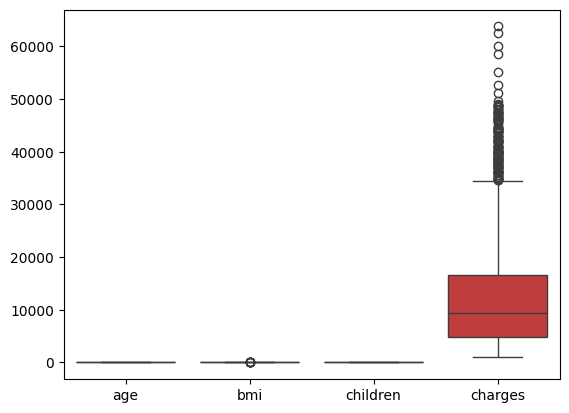

In [ ]:
sns.boxplot(data = insurance_dataframe)
plt.show()

## EDA

### Heatmap

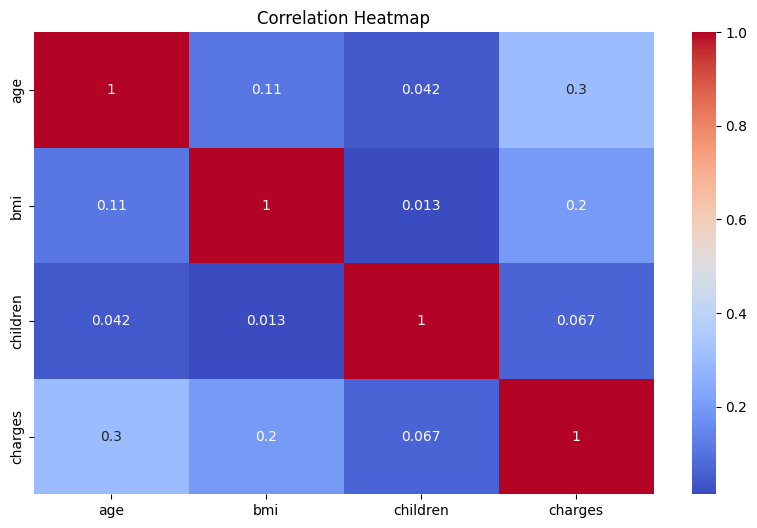

In [ ]:
plt.figure(figsize = (10, 6))
sns.heatmap(insurance_dataframe.corr(numeric_only = True), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### scatterplot

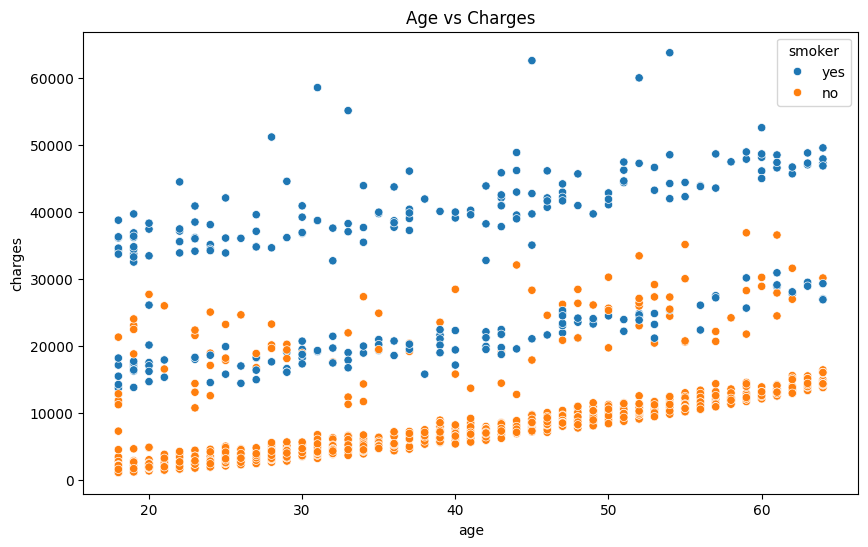

In [ ]:
plt.figure(figsize = (10, 6))
sns.scatterplot(data = insurance_dataframe, x = 'age', y = 'charges', hue = 'smoker')
plt.title('Age vs Charges')
plt.show()

## Feature engineering

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

features = insurance_dataframe.drop('charges', axis = 1)
target = insurance_dataframe['charges']

numerical_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer(
    transformers = [
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop = 'first'), categorical_features)
    ]
)

features_transformed = preprocessor.fit_transform(features)

#**Step 3: Model training and evaluating**

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score

features_train, features_test, target_train, target_test = train_test_split(features_transformed, target, test_size = 0.2, random_state = 42)

linear_regression_model = LinearRegression()
linear_regression_model.fit(features_train, target_train)

ridge_model = Ridge(alpha = 1.0)
ridge_model.fit(features_train, target_train)

kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

ridge_scores = cross_val_score(ridge_model, features_train, target_train, cv = kf, scoring = 'r2')
linear_regression_scores = cross_val_score(linear_regression_model, features_train, target_train, cv = kf, scoring = 'r2')

ridge_mean_score = np.mean(ridge_scores)
linear_regression_mean_score = np.mean(linear_regression_scores)

print(f"Ridge Regression Mean R-squared Score: {ridge_mean_score}")
print(f"Linear Regression Mean R-squared Score: {linear_regression_mean_score}")

target_pred = ridge_model.predict(features_test)
mse = mean_squared_error(target_test, target_pred)
r2 = r2_score(target_test, target_pred)

print(f"Mean Squared Error: {mse}")
print(f"R-squared Score: {r2}")

Ridge Regression Mean R-squared Score: 0.7228083030457235
Linear Regression Mean R-squared Score: 0.722784456117183
Mean Squared Error: 35663190.9847908
R-squared Score: 0.8059210117995655
